# Anime Recommender — PySpark ALS
Java 17 is pre-installed in this container so no `--add-opens` workarounds are needed.

## 1. Spark Session

In [1]:
import os
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, explode
from pyspark.ml.recommendation import ALS
from pyspark.ml.evaluation import RegressionEvaluator

spark = SparkSession.builder \
    .master('local[*]') \
    .appName('AnimeRecommender') \
    .config('spark.ui.port', '4040') \
    .getOrCreate()

spark.sparkContext.setLogLevel('WARN')
print(f'Spark version: {spark.version}')
print('Spark UI: http://localhost:4040')

Spark version: 3.5.0
Spark UI: http://localhost:4040


## 2. Load Data

In [2]:
BASE = '/home/jovyan/work/data/preprocessed'

reviews_data = spark.read.csv(f'{BASE}/reviewsV2.csv', header=True, inferSchema=True)
anime_data   = spark.read.csv(f'{BASE}/animes.csv',    header=True, inferSchema=True)

print('reviews schema:')
reviews_data.printSchema()
print('animes schema:')
anime_data.printSchema()

reviews schema:
root
 |-- _c0: integer (nullable = true)
 |-- uid: integer (nullable = true)
 |-- profile: string (nullable = true)
 |-- anime_uid: integer (nullable = true)
 |-- score: integer (nullable = true)

animes schema:
root
 |-- _c0: integer (nullable = true)
 |-- anime_id: integer (nullable = true)
 |-- genre: string (nullable = true)



## 3. Prepare Final Data
Keep only rows with a valid score (score > 0) to avoid polluting the model with unrated entries.

In [3]:
from pyspark.ml.feature import StringIndexer
review_indexed = StringIndexer(inputCol="profile", outputCol="user_id")
reviews_data_indexed = review_indexed.fit(reviews_data).transform(reviews_data)

final_data = reviews_data_indexed.select(
    col('user_id').cast('integer'),
    col('anime_uid').cast('integer'),
    col('score').cast('float')
).filter(col('score') > 0).filter( col('score') <= 10)  # drop unrated rows

print(f'Total rated reviews: {final_data.count():,}')
final_data.show(7)

Total rated reviews: 130,517
+-------+---------+-----+
|user_id|anime_uid|score|
+-------+---------+-----+
|     32|    34096|  8.0|
|   1104|    34599| 10.0|
|   1825|    28891|  7.0|
|   3796|     2904|  9.0|
|   9589|     4181| 10.0|
|   9872|     2904| 10.0|
|    554|    16664|  6.0|
+-------+---------+-----+
only showing top 7 rows



## 4. Train / Test Split

A naive `randomSplit` puts some users **only** in the test set — ALS has never seen them,
so every prediction gets dropped by `coldStartStrategy='drop'`, leaving an empty DataFrame
and the `Nothing has been added to this summarizer` error.

The fix: split **per user** by holding out 20 % of each user's ratings for testing.
This guarantees every test user also appears in training.

In [4]:
from pyspark.sql.window import Window
from pyspark.sql.functions import rand, row_number, count

# Assign a random rank to each rating within every user
w = Window.partitionBy('user_id').orderBy(rand(seed=42))
ranked = final_data.withColumn('rn', row_number().over(w))

# Also compute how many ratings each user has
user_counts = final_data.groupBy('user_id').agg(count('*').alias('n'))
ranked = ranked.join(user_counts, on='user_id')

# Users with only 1 rating can't contribute to both sets — keep them in train only
train = ranked.filter((col('rn') / col('n') <= 0.8) | (col('n') == 1)).drop('rn', 'n')
test  = ranked.filter((col('rn') / col('n') >  0.8) & (col('n') >  1)).drop('rn', 'n')

print(f'Train size: {train.count():,}')
print(f'Test size:  {test.count():,}')

Train size: 101,755
Test size:  28,762


## 5. Train ALS Model

In [5]:
als = ALS(
    maxIter=10,
    regParam=0.1,
    rank=10,
    userCol='user_id',
    itemCol='anime_uid',
    ratingCol='score',
    coldStartStrategy='drop'  # safe now — all test users exist in train
)

model = als.fit(train)
print('Model trained.')

Model trained.


In [6]:
# Diagnosis cell — run this before anything else
print("Total rows:", final_data.count())
print("Rows with score > 0:", final_data.filter(col('score') > 0).count())
print("Distinct users:", final_data.select('user_id').distinct().count())

# Check score distribution
final_data.groupBy('score').count().orderBy('score').show(20)

Total rows: 130517
Rows with score > 0: 130517
Distinct users: 47884
+-----+-----+
|score|count|
+-----+-----+
|  1.0| 2916|
|  2.0| 3149|
|  3.0| 5726|
|  4.0| 5880|
|  5.0| 8548|
|  6.0|12446|
|  7.0|19064|
|  8.0|23727|
|  9.0|24543|
| 10.0|24518|
+-----+-----+



## 6. Evaluate — RMSE on Test Set

In [7]:
predictions = model.transform(test)

# Sanity check — should not be 0
print(f'Predictions count: {predictions.count():,}')

evaluator = RegressionEvaluator(
    metricName='rmse',
    labelCol='score',
    predictionCol='prediction'
)
rmse = evaluator.evaluate(predictions)
print(f'RMSE: {rmse:.4f}')
# RMSE is on a 1-10 scale; anything below ~1.5 is reasonable for anime ratings

Predictions count: 28,148
RMSE: 3.9451


## 7. Generate Recommendations

In [8]:
# Top 10 anime for every user
user_recs = model.recommendForAllUsers(10)
user_recs.show(5, truncate=False)

# Top 10 users for every anime
anime_recs = model.recommendForAllItems(10)
anime_recs.show(5, truncate=False)

+-------+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|user_id|recommendations                                                                                                                                                                                      |
+-------+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|31     |[{36913, 14.152918}, {10197, 13.709054}, {34376, 13.196474}, {4051, 12.98833}, {36817, 12.874974}, {6823, 12.6951885}, {36291, 12.275733}, {39196, 11.970954}, {3914, 11.665123}, {1385, 11.570452}] |
|34     |[{34376, 12.927806}, {33818, 12.258266}, {18523, 11.932721}, {1926, 11.918077}, {28993, 11.840341}, {2793, 11.724522}, {36913, 11.571662}, {4051, 11.509491}, {

## 8. Recommend for a Specific User

In [9]:
# Pick any uid from the dataset — change this to explore different users
target_uid = final_data.select('user_id').first()[0]
print(f'Generating recommendations for uid: {target_uid}')

target_user = spark.createDataFrame([(target_uid,)], ['user_id'])
user_subset_recs = model.recommendForUserSubset(target_user, 10)

recs_flat = user_subset_recs.select(
    'user_id',
    explode('recommendations').alias('rec')
).select(
    'user_id',
    col('rec.anime_uid'),
    col('rec.rating')
)

recs_flat.show(truncate=False)

Generating recommendations for uid: 32
+-------+---------+---------+
|user_id|anime_uid|rating   |
+-------+---------+---------+
|32     |8333     |15.763646|
|32     |33042    |14.056094|
|32     |3403     |13.518083|
|32     |31564    |13.177989|
|32     |8410     |12.98222 |
|32     |6266     |12.513669|
|32     |36838    |12.353999|
|32     |24415    |12.258432|
|32     |26453    |12.180689|
|32     |1567     |12.171304|
+-------+---------+---------+



## 9. Join with Anime Metadata

In [10]:
# anime_data uses 'anime_id' but recs_flat uses 'anime_uid' — align the key
anime_lookup = anime_data.withColumnRenamed('anime_id', 'anime_uid')

readable_recs = recs_flat \
    .join(anime_lookup, on='anime_uid', how='left') \
    .select('user_id', 'anime_uid', 'genre', 'rating') \
    .orderBy('rating', ascending=False)

readable_recs.show(truncate=False)

+-------+---------+----------------------------------------------------------------------------+---------+
|user_id|anime_uid|genre                                                                       |rating   |
+-------+---------+----------------------------------------------------------------------------+---------+
|32     |8333     |['Fantasy']                                                                 |15.763646|
|32     |33042    |['Comedy', 'Horror']                                                        |14.056094|
|32     |3403     |['Hentai']                                                                  |13.518083|
|32     |31564    |['Slice of Life', 'Comedy', 'School']                                       |13.177989|
|32     |8410     |['Adventure', 'Comedy', 'Sports']                                           |12.98222 |
|32     |6266     |['Drama', 'School', 'Slice of Life']                                        |12.513669|
|32     |36838    |['Action', 'Sci-Fi

## 10. (Optional) Hyperparameter Tuning
This trains 9 models × 3 folds = 27 fits. Skip if your dataset is large and you just want results.

In [11]:
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder

param_grid = ParamGridBuilder() \
    .addGrid(als.rank,     [5, 10, 20]) \
    .addGrid(als.regParam, [0.01, 0.1, 1.0]) \
    .build()

cv = CrossValidator(
    estimator=als,
    estimatorParamMaps=param_grid,
    evaluator=evaluator,
    numFolds=3,
    seed=42
)

cv_model = cv.fit(train)
best_model = cv_model.bestModel
print(f'Best rank:     {best_model.rank}')
print(f'Best regParam: {best_model._java_obj.parent().getRegParam()}')

# Re-evaluate with the best model
best_preds = best_model.transform(test)
best_rmse  = evaluator.evaluate(best_preds)
print(f'Best model RMSE: {best_rmse:.4f}')

Best rank:     20
Best regParam: 1.0
Best model RMSE: 2.6044


## 11. Evaluation of recommendation system

In [12]:
# What % of all anime appear in recommendations?
all_anime_count = final_data.select('anime_uid').distinct().count()

user_recs = model.recommendForAllUsers(10)
recommended_anime = user_recs.select(
    explode('recommendations').alias('rec')
).select(col('rec.anime_uid')).distinct()

coverage = recommended_anime.count() / all_anime_count
print(f'Catalog coverage: {coverage:.2%}')
print(f'')

Catalog coverage: 32.55%



In [13]:
from pyspark.sql.functions import count, desc, avg

# Most popular anime in training data
popular = train.groupBy('anime_uid') \
    .agg(count('*').alias('n_ratings'),
        avg('score').alias('avg_score')) \
    .orderBy(desc('n_ratings'))

test_pop = test.groupBy('anime_uid') \
    .agg(count('*').alias('test_n_ratings')) \
    .orderBy(desc('test_n_ratings'))

# Compare with what gets recommended most often
rec_counts = user_recs.select(
    explode('recommendations').alias('rec')
).select(col('rec.anime_uid')) \
 .groupBy('anime_uid').agg(count('*').alias('times_recommended')) \
 .orderBy(desc('times_recommended'))

# Join to see overlap
joined = popular.join(rec_counts, on='anime_uid').join(test_pop, on='anime_uid')

joined.show(10)

joined.orderBy(desc('times_recommended')).show(10)
joined.orderBy(desc('n_ratings')).show(10)

+---------+---------+-----------------+-----------------+--------------+
|anime_uid|n_ratings|        avg_score|times_recommended|test_n_ratings|
+---------+---------+-----------------+-----------------+--------------+
|     3918|        5|              9.4|             1996|             3|
|     5300|       15|8.933333333333334|              235|             3|
|    22097|        1|              8.0|               41|             1|
|    36538|        7|8.714285714285714|               27|             2|
|      148|        5|              7.8|               70|             1|
|    34591|       11|9.545454545454545|             1300|             6|
|     3226|        3|8.666666666666666|               91|             1|
|    40542|        5|              8.0|               25|             1|
|    19351|        2|              9.0|              189|             2|
|    36982|        2|              8.5|               21|             1|
+---------+---------+-----------------+------------

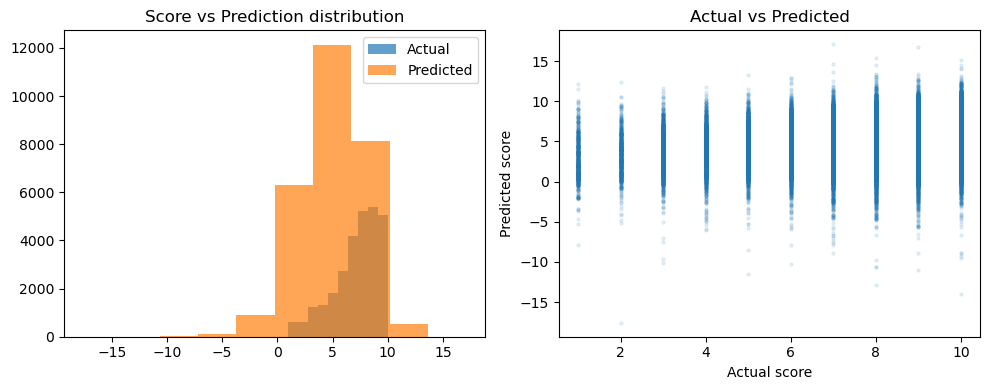

In [14]:
import matplotlib.pyplot as plt
import pandas as pd

preds_pd = predictions.select('score', 'prediction').toPandas()

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.hist(preds_pd['score'],      bins=10, alpha=0.7, label='Actual')
plt.hist(preds_pd['prediction'], bins=10, alpha=0.7, label='Predicted')
plt.legend()
plt.title('Score vs Prediction distribution')

plt.subplot(1, 2, 2)
plt.scatter(preds_pd['score'], preds_pd['prediction'], alpha=0.1, s=5)
plt.xlabel('Actual score')
plt.ylabel('Predicted score')
plt.title('Actual vs Predicted')
plt.tight_layout()
plt.show()

Bad Metric: Because the genres is a list of multiple genres and is always distinct if just one genre is different

In [15]:
from pyspark.sql.functions import avg

# Flatten all recommendations and join with anime metadata
all_recs_flat = user_recs.select(
    'user_id', explode('recommendations').alias('rec')
).select('user_id', col('rec.anime_uid'), col('rec.rating'))

anime_lookup = anime_data.withColumnRenamed('anime_id', 'anime_uid')

recs_with_genre = all_recs_flat.join(anime_lookup, on='anime_uid', how='left')

# How many distinct genres appear per user's top 10?
from pyspark.sql.functions import countDistinct
genre_diversity = recs_with_genre.groupBy('user_id') \
    .agg(countDistinct('genre').alias('distinct_genres'))

genre_per_anime = anime_lookup.agg(countDistinct('genre').alias('distinct_genres')).show()

genre_diversity.select(avg('distinct_genres')).show()


+---------------+
|distinct_genres|
+---------------+
|           4851|
+---------------+

+--------------------+
|avg(distinct_genres)|
+--------------------+
|   9.425361289783643|
+--------------------+

